In [1]:
# import splusdata 
import pandas as pd

In [2]:
df = pd.read_csv("../data/halpha_emitters-gustabin/splus_all_w_distance_cleaned.csv")

In [3]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

def radec_to_galactic(ra_deg, dec_deg):
    """
    Convert equatorial coordinates (RA, Dec) to galactic coordinates (l, b).

    Parameters
    ----------
    ra_deg : float or array-like
        Right Ascension in degrees.
    dec_deg : float or array-like
        Declination in degrees.

    Returns
    -------
    l_deg : ndarray
        Galactic longitude(s) in degrees, in [0, 360).
    b_deg : ndarray
        Galactic latitude(s) in degrees, in [-90, 90].
    """
    coords = SkyCoord(ra=np.array(ra_deg)*u.deg, dec=np.array(dec_deg)*u.deg, frame='icrs')
    gal = coords.galactic
    return gal.l.deg, gal.b.deg

In [4]:
l_deg, b_deg = radec_to_galactic(df['ra'].values, df['dec'].values)

# Append results to original DataFrame
df['l'] = l_deg
df['b'] = b_deg

In [8]:
df.to_csv("../data/halpha_emitters-gustabin/splus_all_w_distance_cleaned.csv", index=False)

In [10]:
from astroquery.xmatch import XMatch
import io
import astropy.units as u

table = XMatch.query(
    cat1=open("../data/halpha_emitters-gustabin/splus_all_w_distance_cleaned.csv"),
    cat2='simbad',
    max_distance=2* u.arcsec,
    colRA1='ra',
    colDec1='dec'
)

In [11]:
table = table.to_pandas()

In [5]:
def pick_distance_kpc(df):
    """
    Choose distance (kpc) with preference:
    r_med_photogeo -> r_med_geo -> 1/parallax (parallax in mas).
    Assumes r_* are in pc.
        """
    
    import numpy as np
    d_pc = np.full(len(df), np.nan, dtype="float64")
    if 'r_med_photogeo' in df.columns:
        arr = pd.to_numeric(df['r_med_photogeo'], errors='coerce')
        d_pc = np.where(np.isfinite(arr), arr, d_pc)
    if 'r_med_geo' in df.columns:
        need = ~np.isfinite(d_pc)
        arr = pd.to_numeric(df.loc[need, 'r_med_geo'], errors='coerce')
        d_pc[need] = arr.values
    return d_pc / 1000.0

In [6]:
# pick_distance_kpc expects a pandas DataFrame (uses .loc/.columns etc.).
# Convert the astropy Table to pandas, compute distances, then attach back.

dist_kpc = pick_distance_kpc(df)
df['distance_kpc'] = dist_kpc

In [7]:
df

,id,ra,dec,parallax,gaia_ruwe,gaia_parallax_over_error,gaia_classprob_dsc_combmod_star,gaia_in_qso_candidates,gaia_in_galaxy_candidates,gaia_phot_bp_rp_excess_factor,...,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,flag,l,b,distance_kpc
0,b'i06MC007700JMF',36.387390,-70.965706,0.368750,1.005816,3.825217,9.999655e-01,0.0,0.0,1.207739,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,292.468750,-44.200987,NaN
1,b'i06MC007700ZJC',36.683662,-70.414670,0.289613,0.983194,1.817915,9.999881e-01,0.0,0.0,1.167722,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,291.963991,-44.629062,NaN
2,b'i06MC013900E66',33.164160,-74.964240,-0.074111,0.967809,-2.753948,9.999993e-01,0.0,0.0,1.155623,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,296.074564,-41.064503,NaN
3,b'i06MC013900GX7',34.814426,-74.883390,-0.116167,1.053277,-0.836411,3.879546e-17,1.0,0.0,1.181219,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295.514172,-40.955181,NaN
4,b'i06MC013900ZG9',33.159626,-74.379130,-0.071390,0.991715,-2.116058,9.999995e-01,0.0,0.0,1.159105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295.755566,-41.598337,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33388,b'i06s21s2800SKE',326.200160,-26.779228,0.101048,0.975007,0.393984,9.427616e-14,1.0,0.0,1.199075,...,1065.16174,763.852417,1591.06616,6513.34082,1986.83557,8141.05371,10133.0,22.324695,-48.656532,6.513341
33389,b'i06s21s2801AVM',327.238130,-26.220474,0.569331,0.964216,4.763207,9.999841e-01,0.0,0.0,1.225111,...,1735.20410,1481.037480,2115.41455,1955.75586,1700.42798,2287.98340,10033.0,23.447176,-49.452781,1.955756
33390,b'i06s22s210086H',315.781460,-28.774582,0.025035,0.929050,0.155903,9.999813e-01,0.0,0.0,1.186074,...,4553.82031,3107.582030,6148.88672,4721.17480,3725.73022,6018.75098,10033.0,16.916910,-40.051225,4.721175
33391,b'i06s22s2101AS5',316.044040,-27.970734,-0.013385,1.015723,-0.038620,1.376581e-05,1.0,0.0,1.246672,...,2498.57153,1896.840330,3302.80469,2338.30908,1975.90662,2952.94727,10033.0,18.008277,-40.097296,2.338309


In [ ]:
tab1 = table[(table['distance_kpc'] < 10.0)&(table['distance_kpc'] > 0)]

In [15]:
tab1

,angDist,id,ra,dec,parallax,gaia_ruwe,gaia_parallax_over_error,gaia_classprob_dsc_combmod_star,gaia_in_qso_candidates,gaia_in_galaxy_candidates,...,V,R,J,H,K,u,g,r,i,z
1000,0.492942,b'i06s38s38003KV',315.904800,-49.894333,0.170490,1.060701,2.961438,9.999172e-01,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1004,1.949642,b'i06s33s2901209',52.047245,-42.297157,0.098838,1.048354,1.601752,4.395393e-15,1.0,0.0,...,NaN,17.309999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1005,0.289759,b'i06s30s3400265',56.105670,-39.450558,-0.150556,0.989718,-1.921384,7.529289e-15,1.0,0.0,...,17.510000,NaN,16.902,16.062,14.830,NaN,NaN,NaN,NaN,NaN
1006,0.712189,b'i06s30s3400RYA',57.163258,-38.663740,0.121621,1.041123,1.142318,2.517683e-15,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1007,0.362011,b'i06s18s0100MRZ',359.426640,-22.431383,-0.330478,1.052667,-1.494516,2.033021e-13,1.0,0.0,...,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4448,0.298087,b'i06s25s6700E9L',344.453400,-32.545036,0.447939,1.005318,3.486988,6.877988e-05,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4449,1.705577,b'i06s25s6700E9L',344.453400,-32.545036,0.447939,1.005318,3.486988,6.877988e-05,1.0,0.0,...,NaN,17.733000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4450,0.221014,b'i06s28s430076B',69.700325,-36.586120,0.083111,1.087419,1.500926,3.953712e-14,1.0,0.0,...,17.500000,NaN,15.940,15.296,14.193,NaN,NaN,NaN,NaN,NaN
4451,0.156992,b'i06s29s1500M20',24.219246,-37.418095,-0.083450,1.002544,-1.305745,4.759784e-04,1.0,0.0,...,18.200001,NaN,16.247,15.573,15.045,NaN,NaN,NaN,NaN,NaN


In [13]:
len(tab1)

1160

In [23]:
tab1.to_csv("tabela_simbad.csv", index=False)

In [14]:
tab1.groupby('main_type').size().sort_values(ascending=False)

main_type
QSO                         354
EclBin                      293
RRLyrae                     139
Seyfert1                     78
CataclyV*                    52
Galaxy                       48
Star                         36
AGN_Candidate                19
Radio                        15
EmissionG                    15
blue                         12
RadioG                        8
Seyfert2                      7
AGN                           7
CataclyV*_Candidate           6
BLLac                         6
RRLyrae_Candidate             6
WhiteDwarf_Candidate          5
PulsV*                        5
HighPM*                       4
GinPair                       4
X                             4
Variable*                     4
WhiteDwarf                    3
Transient                     2
SB*_Candidate                 2
PartofG                       2
delSctV*                      2
PlanetaryNeb                  2
GravLensSystem_Candidate      2
HotSubdwarf_Candidate         

In [ ]:
object_num = 1

ra = df['ra'].values[object_num]
dec = df['dec'].values[object_num]

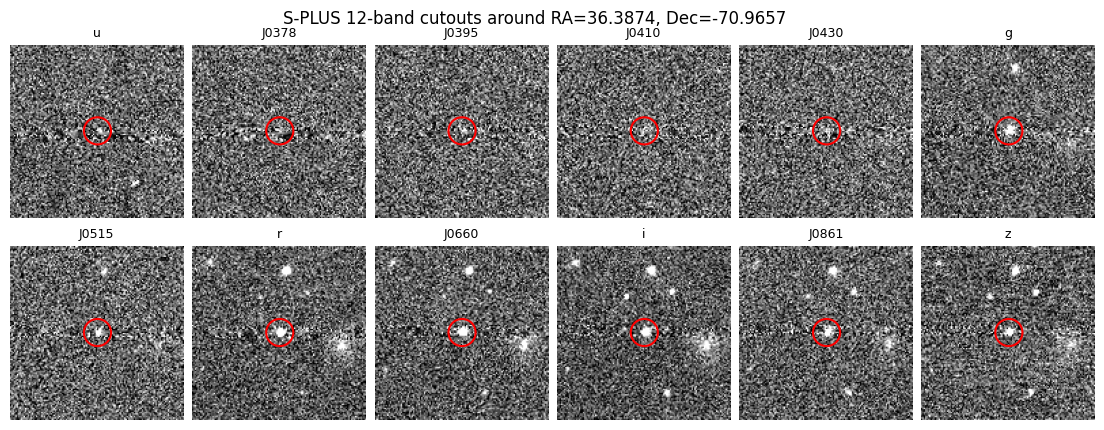

In [45]:
import numpy as np
import matplotlib.pyplot as plt

bands = ['u', 'J0378', 'J0395', 'J0410', 'J0430', 'g',
         'J0515', 'r', 'J0660', 'i', 'J0861', 'z']

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
axes = axes.ravel()
plt.subplots_adjust(wspace=0.05, hspace=0.1)

for ax, band in zip(axes, bands):
    img = conn.stamp(ra, dec, 128, band=band)[1].data
    vmin = np.nanpercentile(img, 5)
    vmax = np.nanpercentile(img, 99)
    ax.imshow(img, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(band, fontsize=9)
    ax.axis('off')

    # --- draw red circle in the center ---
    ny, nx = img.shape
    circ = plt.Circle((nx/2, ny/2), 10, color='red', fill=False, lw=1.5)
    ax.add_patch(circ)

plt.suptitle(f"S-PLUS 12-band cutouts around RA={ra:.4f}, Dec={dec:.4f}", y=0.94)
plt.show()

In [25]:
df.columns

Index(['id', 'ra', 'dec', 'parallax', 'gaia_ruwe', 'gaia_parallax_over_error',
       'gaia_classprob_dsc_combmod_star', 'gaia_in_qso_candidates',
       'gaia_in_galaxy_candidates', 'gaia_phot_bp_rp_excess_factor', 'mag_r',
       'mag_i', 'mag_u', 'mag_g', 'mag_z', 'mag_j0378', 'mag_j0395',
       'mag_j0410', 'mag_j0430', 'mag_j0515', 'mag_j0660', 'mag_j0861',
       'err_mag_r', 'err_mag_i', 'err_mag_u', 'err_mag_g', 'err_mag_z',
       'err_mag_j0378', 'err_mag_j0395', 'err_mag_j0410', 'err_mag_j0430',
       'err_mag_j0515', 'err_mag_j0660', 'err_mag_j0861', 'EW_Ha', 'EW_Ha_err',
       'SNR_EW', 'method', 'gaia_source_id', 'source_id', 'r_med_geo',
       'r_lo_geo', 'r_hi_geo', 'r_med_photogeo', 'r_lo_photogeo',
       'r_hi_photogeo', 'flag'],
      dtype='object')

In [ ]:
J0378,J0395,J0410,J0430,J0515,J0660,J0861


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# --- Given constants ---
W_nb_J0660 = 147.0  # Å
LAMBDA = {
    'u': 3536.0, 'J0378': 3770.0, 'J0395': 3940.0, 'J0410': 4094.0, 'J0430': 4292.0,
    'g': 4751.0, 'J0515': 5133.0, 'r': 6258.0, 'J0660': 6614.0, 'i': 7690.0,
    'J0861': 8611.0, 'z': 8831.0
}
LAM_HA = 6563.0

# Column mapping in your dataframe
MAG_COL = {
    'u':'mag_u','g':'mag_g','r':'mag_r','i':'mag_i','z':'mag_z',
    'J0378':'mag_j0378','J0395':'mag_j0395','J0410':'mag_j0410','J0430':'mag_j0430',
    'J0515':'mag_j0515','J0660':'mag_j0660','J0861':'mag_j0861'
}
ERR_COL = {
    'u':'err_mag_u','g':'err_mag_g','r':'err_mag_r','i':'err_mag_i','z':'err_mag_z',
    'J0378':'err_mag_j0378','J0395':'err_mag_j0395','J0410':'err_mag_j0410','J0430':'err_mag_j0430',
    'J0515':'err_mag_j0515','J0660':'err_mag_j0660','J0861':'err_mag_j0861'
}

CONTINUUM_BANDS = ['u','J0378','J0395','J0410','J0430','g','J0515','r','i','J0861','z']  # exclude J0660
ALL_BANDS = ['u','J0378','J0395','J0410','J0430','g','J0515','r','J0660','i','J0861','z']

def _mags_to_flux(mag, dmag):
    """Return flux ~ 10^(-0.4 m) and its error (linearized)."""
    f = 10.0**(-0.4 * mag)
    k = np.log(10.0)/2.5
    df = f * k * dmag
    return f, df

def _weighted_poly_fit_lnflux(lam, ln_f, s_ln_f, lam0=LAM_HA, deg=2):
    """Weighted LS fit in ln-flux space (stable + symmetric errors)."""
    t = (lam - lam0) / 1000.0
    X = np.vstack([np.ones_like(t), t, t**2])[:deg+1].T
    w = 1.0 / np.maximum(s_ln_f**2, 1e-30)
    XT_W = X.T * w
    A = XT_W @ X
    b = XT_W @ ln_f
    beta = np.linalg.lstsq(A, b, rcond=None)[0]
    # residual variance for covariance estimate
    yhat = X @ beta
    res = ln_f - yhat
    dof = max(1, len(lam) - (deg+1))
    s2_hat = (w * res**2).sum() / w.sum()
    Cov = np.linalg.pinv(A) * s2_hat
    return beta, Cov

def _predict_lnflux(beta, Cov, lam_eval, lam0=LAM_HA):
    t0 = (lam_eval - lam0) / 1000.0
    x0 = np.array([1.0, t0, t0**2])[:len(beta)]
    ln_f_hat = float(x0 @ beta)
    var_ln_f_hat = float(x0 @ Cov @ x0)
    return ln_f_hat, var_ln_f_hat

def plot_splus_12band_spectrum(row, id_col='id', normalize=True, show_continuum=True):
    """
    Plot 12-band SED (flux vs wavelength) with errors.
    - Excludes J0660 from the continuum fit.
    - Highlights J0660 and Hα.
    - normalize=True scales fluxes by median continuum to make shapes comparable.
    """
    # Collect mags/errors per band
    lam, mag, dmag = [], [], []
    for b in ALL_BANDS:
        m = row.get(MAG_COL[b], np.nan)
        dm = row.get(ERR_COL[b], np.nan)
        lam.append(LAMBDA[b]); mag.append(m); dmag.append(dm)
    lam = np.array(lam, dtype=float)
    mag = np.array(mag, dtype=float)
    dmag = np.array(dmag, dtype=float)

    # Convert to flux + errors
    f, df = _mags_to_flux(mag, dmag)

    # Optional normalization by median of continuum points
    cont_mask = np.isfinite(mag)
    for b in ['J0660']:  # explicitly exclude NB from continuum calc
        cont_mask[ALL_BANDS.index(b)] = False
    if normalize:
        norm = np.nanmedian(f[cont_mask])
        if np.isfinite(norm) and norm > 0:
            f  = f / norm
            df = df / norm

    # Prepare continuum fit (ln-flux WLS over continuum bands)
    if show_continuum:
        cont_lam = lam[cont_mask & np.isfinite(f) & np.isfinite(df)]
        cont_f   = f  [cont_mask & np.isfinite(f) & np.isfinite(df)]
        cont_df  = df [cont_mask & np.isfinite(f) & np.isfinite(df)]
        if len(cont_lam) >= 3:
            lnF = np.log(np.clip(cont_f, 1e-300, None))
            s_lnF = np.where(cont_f > 0, cont_df / cont_f, np.inf)
            beta, Cov = _weighted_poly_fit_lnflux(cont_lam, lnF, s_lnF, lam0=LAM_HA, deg=2)
        else:
            beta = Cov = None
    else:
        beta = Cov = None

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4.8))

    # Error bars and connecting line
    ax.errorbar(lam, f, yerr=df, fmt='o', ms=4, lw=1, capsize=2, alpha=0.9)
    ax.plot(lam, f, lw=1, alpha=0.5)

    # Highlight J0660 point
    try:
        j_idx = ALL_BANDS.index('J0660')
        ax.plot([lam[j_idx]], [f[j_idx]], 'o', ms=6, mfc='none', mec='red', mew=1.6, label='J0660')
        # Shade the J0660 bandpass
        ax.axvspan(LAMBDA['J0660'] - W_nb_J0660/2, LAMBDA['J0660'] + W_nb_J0660/2,
                   alpha=0.08, edgecolor='none')
    except Exception:
        pass

    # Mark Hα rest wavelength
    ax.axvline(LAM_HA, ls='--', lw=1.2, alpha=0.6)

    # Overlay continuum fit curve
    if beta is not None and Cov is not None:
        xx = np.linspace(3400, 9000, 400)
        lnF_hat = np.array([_predict_lnflux(beta, Cov, _x, lam0=LAM_HA)[0] for _x in xx])
        F_hat = np.exp(lnF_hat)
        ax.plot(xx, F_hat, lw=2, alpha=0.8, label='Continuum fit (no J0660)')

    # Labels
    title = f"ID: {row[id_col]}" if id_col in row and pd.notna(row[id_col]) else "S-PLUS 12-band SED"
    ax.set_title(title)
    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel("Flux (relative units)" if normalize else "Flux (arb. units)")
    ax.set_xlim(3400, 9000)
    # invert y-axis for astronomical flux convention

    ax.grid(alpha=0.25)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [50]:
df

,id,ra,dec,parallax,gaia_ruwe,gaia_parallax_over_error,gaia_classprob_dsc_combmod_star,gaia_in_qso_candidates,gaia_in_galaxy_candidates,gaia_phot_bp_rp_excess_factor,...,method,gaia_source_id,source_id,r_med_geo,r_lo_geo,r_hi_geo,r_med_photogeo,r_lo_photogeo,r_hi_photogeo,flag
1,b'i06MC00770022C',39.314224,-71.615180,NaN,NaN,NaN,9.925787e-01,0.0,0.0,8.778375,...,WLS-continuum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,b'i06MC007700JMF',36.387390,-70.965706,0.368750,1.005816,3.825217,9.999655e-01,0.0,0.0,1.207739,...,WLS-continuum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,b'i06MC007700ZJC',36.683662,-70.414670,0.289613,0.983194,1.817915,9.999881e-01,0.0,0.0,1.167722,...,WLS-continuum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,b'i06MC013900E66',33.164160,-74.964240,-0.074111,0.967809,-2.753948,9.999993e-01,0.0,0.0,1.155623,...,WLS-continuum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,b'i06MC013900GX7',34.814426,-74.883390,-0.116167,1.053277,-0.836411,3.879546e-17,1.0,0.0,1.181219,...,WLS-continuum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665246,b'i06s21s2800SKE',326.200160,-26.779228,0.101048,0.975007,0.393984,9.427616e-14,1.0,0.0,1.199075,...,WLS-continuum,6.811163e+18,6.811163e+18,1065.16174,763.852417,1591.06616,6513.34082,1986.83557,8141.05371,10133.0
665256,b'i06s21s2801AVM',327.238130,-26.220474,0.569331,0.964216,4.763207,9.999841e-01,0.0,0.0,1.225111,...,WLS-continuum,6.811285e+18,6.811285e+18,1735.20410,1481.037480,2115.41455,1955.75586,1700.42798,2287.98340,10033.0
665263,b'i06s22s210086H',315.781460,-28.774582,0.025035,0.929050,0.155903,9.999813e-01,0.0,0.0,1.186074,...,WLS-continuum,6.800606e+18,6.800606e+18,4553.82031,3107.582030,6148.88672,4721.17480,3725.73022,6018.75098,10033.0
665281,b'i06s22s2101AS5',316.044040,-27.970734,-0.013385,1.015723,-0.038620,1.376581e-05,1.0,0.0,1.246672,...,WLS-continuum,6.801077e+18,6.801077e+18,2498.57153,1896.840330,3302.80469,2338.30908,1975.90662,2952.94727,10033.0


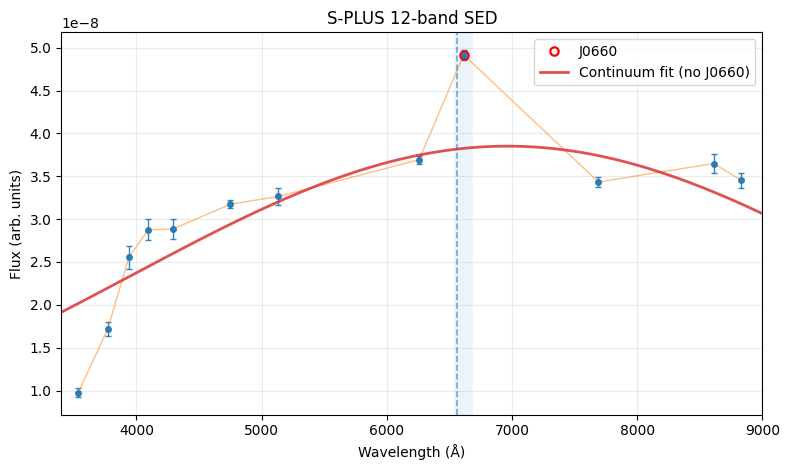

In [51]:
plot_splus_12band_spectrum(df.iloc[11], id_col='splus_id', normalize=False, show_continuum=True)

In [5]:
import pandas as pd
final = pd.read_csv("../data/halpha_emitters-gustabin/splus_all_w_distance.csv")

/tmp/ipykernel_36375/1333455996.py:2: DtypeWarning: Columns (31,37) have mixed types. Specify dtype option on import or set low_memory=False.
  final = pd.read_csv("../data/halpha_emitters-gustabin/splus_all_w_distance.csv")


In [6]:
final = final[(final['mag_r'] < 19) & (final['mag_r'] > 14.5)]
final = final[(final['err_mag_j0660'] < 0.2)&
        (final['err_mag_i'] < 0.2)&
        (final['err_mag_r'] < 0.2)&
        (final['mag_j0660']/final['err_mag_j0660'] > 10)&
        (final['mag_i']/final['err_mag_i'] > 10)&
        (final['mag_r']/final['err_mag_r'] > 10)&
        (final['gaia_ruwe'] < 1.6)]

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) CONFIG
# =========================
MAX_DIST_KPC = 10.0
USE_HDBSCAN = True         # if installed, use it; else falls back to DBSCAN
# HDBSCAN params (good for many small/filamentary groups)
HDBSCAN_MIN_CLUSTER_SIZE = 8
HDBSCAN_MIN_SAMPLES     = 3
HDBSCAN_CSEPS           = 0.05  # cluster_selection_epsilon (kpc-ish scale)

# DBSCAN fallback params (tune to your scale, in kpc)
DBSCAN_EPS         = 0.30
DBSCAN_MIN_SAMPLES = 8

# Output (optional)
SAVE_PER_SOURCE_CSV = None   # e.g., "filament_labels.csv"
SAVE_SUMMARY_CSV    = None   # e.g., "filament_clusters_summary.csv"

# Plot ranges
XY_RANGE = (-10, 10, -10, 10)
XZ_RANGE = (-10, 10,  -5,  5)

# =========================
# 1) COORDINATE UTILS
# =========================
def pick_distance_kpc(df):
    """
    Choose distance (kpc) with preference:
    r_med_photogeo -> r_med_geo -> 1/parallax (parallax in mas).
    Assumes r_* are in pc.
    """
    d_pc = np.full(len(df), np.nan, dtype="float64")
    if 'r_med_photogeo' in df.columns:
        arr = pd.to_numeric(df['r_med_photogeo'], errors='coerce')
        d_pc = np.where(np.isfinite(arr), arr, d_pc)
    if 'r_med_geo' in df.columns:
        need = ~np.isfinite(d_pc)
        arr = pd.to_numeric(df.loc[need, 'r_med_geo'], errors='coerce')
        d_pc[need] = arr.values
    if 'parallax' in df.columns:
        need = ~np.isfinite(d_pc)
        par = pd.to_numeric(df.loc[need, 'parallax'], errors='coerce').to_numpy()
        with np.errstate(divide='ignore', invalid='ignore'):
            d_from_par_pc = 1000.0 / par  # pc
        d_pc[need] = d_from_par_pc
    return d_pc / 1000.0

def radec_to_galactic(ra_deg, dec_deg):
    """ICRS (deg) -> Galactic (l,b) deg using the standard J2000 matrix."""
    ra  = np.radians(ra_deg)
    dec = np.radians(dec_deg)
    x_icrs = np.cos(dec) * np.cos(ra)
    y_icrs = np.cos(dec) * np.sin(ra)
    z_icrs = np.sin(dec)
    v = np.vstack([x_icrs, y_icrs, z_icrs])
    R = np.array([
        [-0.0548755604162154, -0.8734370902348850, -0.4838350155487132],
        [ 0.4941094278755837, -0.4448296299600112,  0.7469822444972189],
        [-0.8676661490190047, -0.1980763734312015,  0.4559837761750669]
    ])
    g = R @ v
    x_gal, y_gal, z_gal = g
    l = np.degrees(np.arctan2(y_gal, x_gal)) % 360.0
    b = np.degrees(np.arcsin(z_gal))
    return l, b

def gal_to_heliocentric_xyz(l_deg, b_deg, d_kpc):
    """Galactic (l,b, d[kpc]) -> Heliocentric Cartesian (X,Y,Z) in kpc."""
    l = np.radians(l_deg)
    b = np.radians(b_deg)
    cosb = np.cos(b)
    x = d_kpc * cosb * np.cos(l)
    y = d_kpc * cosb * np.sin(l)
    z = d_kpc * np.sin(b)
    return x, y, z

def build_xyz(df, max_dist_kpc=MAX_DIST_KPC):
    """Return XYZ (kpc) and valid row index within max_dist_kpc."""
    d_kpc = pick_distance_kpc(df)
    ok = np.isfinite(d_kpc) & (d_kpc > 0) & (d_kpc <= max_dist_kpc)
    if not np.any(ok):
        raise ValueError("No valid distances within the given max_dist_kpc.")
    l_deg, b_deg = radec_to_galactic(df.loc[ok, 'ra'].astype(float),
                                     df.loc[ok, 'dec'].astype(float))
    x, y, z = gal_to_heliocentric_xyz(l_deg, b_deg, d_kpc[ok])
    return x, y, z, df.index[ok]

# =========================
# 2) KDE MAPS
# =========================
def kde_density_2d(x, y, grids=400, extent=None, bw='scott'):
    """2D Gaussian KDE. Uses scipy if available; else a numpy fallback."""
    try:
        from scipy.stats import gaussian_kde
        use_scipy = True
    except Exception:
        use_scipy = False

    if extent is None:
        pad = 0.05 * max((x.max()-x.min()), (y.max()-y.min()))
        extent = [x.min()-pad, x.max()+pad, y.min()-pad, y.max()+pad]

    X = np.linspace(extent[0], extent[1], grids)
    Y = np.linspace(extent[2], extent[3], grids)
    XX, YY = np.meshgrid(X, Y, indexing='xy')

    if use_scipy:
        kde = gaussian_kde(np.vstack([x, y]), bw_method=bw)
        ZZ = kde.evaluate(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
    else:
        # slow fallback
        n = len(x)
        sx = np.std(x); sy = np.std(y)
        h = (n**(-1/6.)) * np.sqrt((sx**2 + sy**2)/2.0) if bw == 'scott' else float(bw)
        dx = (XX[...,None] - x[None,None,:]) / h
        dy = (YY[...,None] - y[None,None,:]) / h
        K = np.exp(-0.5*(dx*dx + dy*dy)) / (2*np.pi*h*h)
        ZZ = K.sum(axis=2) / max(1, n)

    return XX, YY, ZZ, extent


# =========================
# 3) CLUSTERING
# =========================
def run_hdbscan_or_dbscan(x, y, z,
                          prefer_hdbscan=USE_HDBSCAN,
                          hdb_min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
                          hdb_min_samples=HDBSCAN_MIN_SAMPLES,
                          hdb_cseps=HDBSCAN_CSEPS,
                          db_eps=DBSCAN_EPS,
                          db_min_samples=DBSCAN_MIN_SAMPLES):
    coords = np.column_stack([x, y, z])

    labels = None
    algo = "DBSCAN"
    clusterer = None

    if prefer_hdbscan:
        try:
            import hdbscan
            clusterer = hdbscan.HDBSCAN(min_cluster_size=hdb_min_cluster_size,
                                        min_samples=hdb_min_samples,
                                        cluster_selection_epsilon=hdb_cseps,
                                        # metric='euclidean' (default)
                                        )
            labels = clusterer.fit_predict(coords)
            algo = "HDBSCAN"
        except Exception as e:
            print(f"[warn] HDBSCAN unavailable ({e}). Falling back to DBSCAN.")

    if labels is None:
        from sklearn.cluster import DBSCAN
        db = DBSCAN(eps=db_eps, min_samples=db_min_samples, metric='euclidean', n_jobs=-1)
        labels = db.fit_predict(coords)

    return labels, coords, algo, clusterer

# =========================
# 4) SHAPE (PCA) ANALYSIS
# =========================
def compute_cluster_shapes(coords, labels):
    """Return DataFrame with per-cluster size, center, and elongation (PCA)."""
    from sklearn.decomposition import PCA

    recs = []
    clust_ids = np.unique(labels)
    clust_ids = clust_ids[clust_ids != -1]
    for cid in clust_ids:
        pts = coords[labels == cid]
        if len(pts) < 5:
            continue
        center = pts.mean(axis=0)
        pca = PCA(n_components=3).fit(pts)
        var = pca.explained_variance_ratio_
        # Elongation: leading axis dominance (bigger means more filament-like)
        elong = var[0] / max(1e-9, var[1])
        recs.append({
            "cluster": int(cid),
            "n": int(len(pts)),
            "center_x": float(center[0]),
            "center_y": float(center[1]),
            "center_z": float(center[2]),
            "var1": float(var[0]),
            "var2": float(var[1]),
            "var3": float(var[2]),
            "elongation": float(elong)
        })
    return pd.DataFrame(recs).sort_values(["n", "elongation"], ascending=[False, False])



def drop_largest_clusters(labels, k=1, min_label=0):
    """
    Turn the K largest clusters (with label >= min_label) into noise (-1).
    Noise (-1) stays unchanged.

    Parameters
    ----------
    labels : array-like of int
        Cluster labels (e.g., from HDBSCAN/DBSCAN). -1 = noise.
    k : int
        How many largest clusters to drop.
    min_label : int
        Only consider clusters with label >= min_label for dropping.

    Returns
    -------
    labels_out : np.ndarray
        Copy of labels with the K largest clusters relabeled to -1.
    """
    lab = np.asarray(labels).copy()
    valid = lab >= min_label
    if not np.any(valid) or k <= 0:
        return lab

    ids, counts = np.unique(lab[valid], return_counts=True)
    order = np.argsort(-counts)  # descending by size
    to_drop = ids[order[:min(k, len(ids))]]
    for cid in to_drop:
        lab[lab == cid] = -1
    return lab


def analyze_filaments(df,
                      max_dist_kpc=10.0,
                      draw_kde=True,
                      elongation_threshold=3.0,
                      drop_biggest=0,          # NEW: number of largest clusters to re-label as noise
                      drop_at_least_label=0    # NEW: only drop clusters with label >= this
                      ):
    """
    Full pipeline:
      - build heliocentric XYZ within `max_dist_kpc`
      - optional KDE maps (XY, XZ)
      - clustering (HDBSCAN→DBSCAN)
      - OPTIONAL: drop the K largest clusters (relabel as noise)
      - PCA-based elongation per remaining cluster
      - plots colored by elongation
      - optional CSV outputs

    Parameters
    ----------
    df : pandas.DataFrame
        Input table (Hα-only in your use case) with columns 'ra','dec' and distances
        ('r_med_photogeo'/'r_med_geo' or 'parallax').
    max_dist_kpc : float
        Keep only sources with distance ≤ this value.
    draw_kde : bool
        If True, draw KDE density maps in XY and XZ.
    elongation_threshold : float
        Threshold to print list of filament-candidate cluster IDs (var1/var2 ≥ threshold).
    drop_biggest : int
        If >0, relabel the K largest clusters as noise (-1) before shape analysis/plots.
    drop_at_least_label : int
        Only consider clusters with label ≥ this when selecting the "largest" to drop.

    Returns
    -------
    dict with keys:
        index_valid, x, y, z, labels, point_elongation, shape_df, algo
    """
    # 1) Build positions
    x, y, z, idx = build_xyz(df, max_dist_kpc=max_dist_kpc)

    # 3) Clustering in 3D
    labels, coords, algo, clusterer = run_hdbscan_or_dbscan(x, y, z)
    print(f"[info] Clustering algorithm used: {algo}")
    print(f"[info] Found {len(np.unique(labels[labels!=-1]))} clusters; noise points: {np.sum(labels==-1)}")

    # 3b) Optionally drop the biggest clusters (relabel to -1)
    if drop_biggest > 0:
        labels = drop_largest_clusters(labels, k=drop_biggest, min_label=drop_at_least_label)
        print(f"[info] Dropped the {drop_biggest} largest cluster(s) (labels ≥ {drop_at_least_label}). "
              f"Remaining clusters: {len(np.unique(labels[labels!=-1]))}; "
              f"noise points: {np.sum(labels==-1)}")

    # 4) Shape/elongation per cluster
    shape_df = compute_cluster_shapes(coords, labels)
    if shape_df.empty:
        print("[warn] No clusters large enough for PCA shape analysis after dropping (if any).")
    else:
        print("\nTop clusters by size and elongation:")
        print(shape_df.head(15).to_string(index=False))

    # 5) Map elongation to each point (for continuous coloring)
    elong_by_label = {row.cluster: row.elongation for _, row in shape_df.iterrows()}
    point_elong = np.array([elong_by_label.get(int(c), np.nan) if c != -1 else np.nan for c in labels])

    # 7) Report filament-like clusters
    if not shape_df.empty:
        fil_ids = shape_df.loc[shape_df['elongation'] >= elongation_threshold, 'cluster'].tolist()
        if fil_ids:
            print(f"\n[info] Filament-candidates (elongation ≥ {elongation_threshold}): {fil_ids}")
        else:
            print(f"\n[info] No clusters exceed elongation threshold {elongation_threshold}.")

    # 8) Optional outputs
    if SAVE_PER_SOURCE_CSV:
        out = df.loc[idx].copy()
        out['cluster_id'] = labels
        out['elongation'] = point_elong
        out.to_csv(SAVE_PER_SOURCE_CSV, index=False)
        print(f"[info] Per-source labels saved to {SAVE_PER_SOURCE_CSV}")

    if SAVE_SUMMARY_CSV and (shape_df is not None) and (not shape_df.empty):
        shape_df.to_csv(SAVE_SUMMARY_CSV, index=False)
        print(f"[info] Cluster summary saved to {SAVE_SUMMARY_CSV}")

    return {
        "index_valid": idx,
        "x": x, "y": y, "z": z,
        "labels": labels,
        "point_elongation": point_elong,
        "shape_df": shape_df,
        "algo": algo
    }

In [26]:
import numpy as np
import pandas as pd

# =========================
# CONFIG (tune as needed)
# =========================
EXTENT_SIGMA = 2.0          # diameter = 2 * EXTENT_SIGMA * σ  (e.g., 2→ ~4σ diameter)
RADIAL_ALIGN_MIN = 0.85     # |cos(angle)| threshold for radial alignment
RADIAL_ELONG_MIN = 10.0     # elongation (var1/var2) threshold for “fingers”
RADIAL_MIN_POINTS = 50      # ignore tiny clusters for radial-flagging

# Optional: rule-based filters for remaining clusters
# Example: drop clusters that are too elongated OR too large
DROP_RULES = {
    "max_elongation": 10.0,   # drop if elongation >= this
    "max_members":    500,    # drop if n >= this
    # You can add min/max extent in pc if you like, e.g.:
    # "max_extent_pc_1": 200.0
}

# Optional output files (set to None to skip saving)
SAVE_PER_SOURCE_CSV = None         # e.g., "clean_per_source.csv"
SAVE_CLUSTER_SUMMARY_CSV = None    # e.g., "clean_cluster_summary.csv"

# =========================
# CORE HELPERS
# =========================
def _compute_cluster_shapes_from_coords(coords, labels, extent_sigma=EXTENT_SIGMA):
    """
    Compute per-cluster PCA, shape ratios, physical extents (pc) and radial alignment.

    Returns:
        shape_df: DataFrame with one row per cluster (label != -1)
    """
    from sklearn.decomposition import PCA

    rows = []
    clust_ids = np.unique(labels)
    clust_ids = clust_ids[clust_ids != -1]

    for cid in clust_ids:
        pts = coords[labels == cid]
        if len(pts) < 5:
            continue

        center = pts.mean(axis=0)
        pca = PCA(n_components=3).fit(pts)

        # Variances along PCA axes in kpc^2 and stds in kpc
        var_kpc2 = pca.explained_variance_
        std_kpc  = np.sqrt(var_kpc2)

        # Diameter along each PCA axis (kpc) then to pc
        extent_kpc = 2.0 * extent_sigma * std_kpc
        extent_pc  = extent_kpc * 1000.0

        # Ratios for shape metrics (unitless)
        var_ratio = pca.explained_variance_ratio_
        elong = var_ratio[0] / max(1e-12, var_ratio[1])

        # Radial alignment between PC1 direction and center vector
        v1 = pca.components_[0]                   # unit vector along PC1
        r  = center / (np.linalg.norm(center) + 1e-12)
        radial_align = abs(np.dot(v1, r))         # in [0,1]; 1 = perfectly radial

        rows.append({
            "cluster": int(cid),
            "n": int(len(pts)),
            "center_x": float(center[0]),
            "center_y": float(center[1]),
            "center_z": float(center[2]),
            "var1": float(var_ratio[0]),
            "var2": float(var_ratio[1]),
            "var3": float(var_ratio[2]),
            "elongation": float(elong),
            "extent_pc_1": float(extent_pc[0]),
            "extent_pc_2": float(extent_pc[1]),
            "extent_pc_3": float(extent_pc[2]),
            "extent_kpc_1": float(extent_kpc[0]),
            "extent_kpc_2": float(extent_kpc[1]),
            "extent_kpc_3": float(extent_kpc[2]),
            "radial_align": float(radial_align),
        })

    shape_df = pd.DataFrame(rows).sort_values(["n", "elongation"], ascending=[False, False])
    return shape_df

def _flag_radial_fingers(shape_df,
                         align_min=RADIAL_ALIGN_MIN,
                         elong_min=RADIAL_ELONG_MIN,
                         min_points=RADIAL_MIN_POINTS):
    """Return list of cluster IDs that look like radial distance-axis 'fingers'."""
    if shape_df is None or shape_df.empty:
        return []
    bad = shape_df[
        (shape_df["radial_align"] >= align_min) &
        (shape_df["elongation"] >= elong_min) &
        (shape_df["n"] >= min_points)
    ]
    return bad["cluster"].astype(int).tolist()

def _apply_drop_rules(shape_df, rules):
    """Return list of cluster IDs to drop based on rule dict."""
    if shape_df is None or shape_df.empty or not rules:
        return []
    mask = pd.Series(True, index=shape_df.index)
    if "max_elongation" in rules:
        mask &= shape_df["elongation"] < rules["max_elongation"]
    if "max_members" in rules:
        mask &= shape_df["n"] < rules["max_members"]
    if "max_extent_pc_1" in rules:
        mask &= shape_df["extent_pc_1"] < rules["max_extent_pc_1"]
    if "max_extent_pc_2" in rules:
        mask &= shape_df["extent_pc_2"] < rules["max_extent_pc_2"]
    if "max_extent_pc_3" in rules:
        mask &= shape_df["extent_pc_3"] < rules["max_extent_pc_3"]
    # clusters NOT satisfying mask should be dropped
    to_drop = shape_df.loc[~mask, "cluster"].astype(int).tolist()
    return to_drop

# =========================
# MAIN ENTRY (from your `res`)
# =========================
def postprocess_from_res(res,
                         df_original=None,
                         save_per_source_csv=SAVE_PER_SOURCE_CSV,
                         save_cluster_summary_csv=SAVE_CLUSTER_SUMMARY_CSV,
                         extent_sigma=EXTENT_SIGMA,
                         radial_align_min=RADIAL_ALIGN_MIN,
                         radial_elong_min=RADIAL_ELONG_MIN,
                         radial_min_points=RADIAL_MIN_POINTS,
                         drop_rules=DROP_RULES):
    """
    Start from `res` (output of analyze_filaments):
      - recompute shape table with physical extents (pc)
      - remove radial distance-axis 'fingers'
      - apply rule-based filters (elongation, size, etc.)
      - return cleaned per-source and per-cluster tables
      - optionally save CSVs

    Args:
        res: dict from analyze_filaments()
        df_original: original DataFrame that fed analyze_filaments (to recover columns)
                     If None, per-source output includes only 'cluster_id' and metrics.
    Returns:
        dict with:
          - labels_clean (np.ndarray)
          - kept_cluster_ids (list[int])
          - dropped_cluster_ids (list[int])
          - per_source_df (DataFrame; indexed like df_original where possible)
          - cluster_summary_df (DataFrame)
    """
    # Rebuild coords and labels
    x = np.asarray(res["x"]); y = np.asarray(res["y"]); z = np.asarray(res["z"])
    labels = np.asarray(res["labels"])
    idx = res["index_valid"]               # index into df_original (if provided)
    coords = np.column_stack([x, y, z])

    # Compute shapes (with sizes and radial alignment)
    shape_df = _compute_cluster_shapes_from_coords(coords, labels, extent_sigma=extent_sigma)
    if shape_df.empty:
        print("[warn] No clusters available for shape analysis.")
        labels_clean = labels.copy()
        kept = []
        dropped = []
        # Per-source table
        per_source_df = (df_original.loc[idx].copy() if df_original is not None else pd.DataFrame(index=np.arange(len(labels))))
        per_source_df["cluster_id"] = labels_clean
        return {
            "labels_clean": labels_clean,
            "kept_cluster_ids": kept,
            "dropped_cluster_ids": dropped,
            "per_source_df": per_source_df,
            "cluster_summary_df": shape_df
        }

    # 1) Remove radial-finger artifacts
    radial_bad = _flag_radial_fingers(shape_df,
                                      align_min=radial_align_min,
                                      elong_min=radial_elong_min,
                                      min_points=radial_min_points)
    labels_step = labels.copy()
    for cid in radial_bad:
        labels_step[labels_step == cid] = -1

    # 2) Recompute shapes after removing radial-fingers
    shape_df2 = _compute_cluster_shapes_from_coords(coords, labels_step, extent_sigma=extent_sigma)

    # 3) Apply rule-based drops (elongation, size, etc.)
    rule_bad = _apply_drop_rules(shape_df2, drop_rules)

    labels_clean = labels_step.copy()
    for cid in rule_bad:
        labels_clean[labels_clean == cid] = -1

    # 4) Final shapes after all drops (for reporting/saving)
    shape_df_final = _compute_cluster_shapes_from_coords(coords, labels_clean, extent_sigma=extent_sigma)

    dropped = sorted(set(radial_bad) | set(rule_bad))
    kept = sorted(shape_df_final["cluster"].astype(int).tolist())

    # 5) Build per-source table (map cluster metrics back to each member)
    #    For convenience, we attach per-cluster metrics to each member row.
    metric_cols = ["elongation", "radial_align", "extent_pc_1", "extent_pc_2", "extent_pc_3",
                   "extent_kpc_1", "extent_kpc_2", "extent_kpc_3"]
    metrics_by_cluster = shape_df_final.set_index("cluster")[metric_cols].to_dict(orient="index")

    # Base per-source frame
    if df_original is not None:
        per_source_df = df_original.loc[idx].copy()
    else:
        per_source_df = pd.DataFrame(index=np.arange(len(labels_clean)))

    per_source_df["cluster_id"] = labels_clean

    # attach metrics
    def _get_metric(arr_label, key):
        out = np.full(arr_label.shape, np.nan, dtype=float)
        for k, v in metrics_by_cluster.items():
            sel = (arr_label == int(k))
            if np.any(sel):
                out[sel] = v[key]
        return out

    for k in metric_cols:
        per_source_df[f"cluster_{k}"] = _get_metric(labels_clean, k)

    # 6) Save CSVs (optional)
    if save_per_source_csv:
        per_source_df.to_csv(save_per_source_csv, index=True)
        print(f"[info] Saved per-source table to: {save_per_source_csv}")
    if save_cluster_summary_csv and not shape_df_final.empty:
        shape_df_final.to_csv(save_cluster_summary_csv, index=False)
        print(f"[info] Saved cluster summary to: {save_cluster_summary_csv}")

    # 7) Report
    print(f"[info] Dropped {len(dropped)} clusters (radial artifacts {len(radial_bad)} + rule-based {len(rule_bad)})")
    print(f"[info] Kept {len(kept)} clusters. Noise points: {(labels_clean == -1).sum()}")

    return {
        "labels_clean": labels_clean,
        "kept_cluster_ids": kept,
        "dropped_cluster_ids": dropped,
        "per_source_df": per_source_df,
        "cluster_summary_df": shape_df_final
    }

# =========================
# EXAMPLE USAGE
# =========================
# Assuming you already have:
#   res   = analyze_filaments(final, ...)
#   final = original DataFrame used in analyze_filaments
#
# out = postprocess_from_res(res, df_original=final,
#                            save_per_source_csv="clean_per_source.csv",
#                            save_cluster_summary_csv="clean_cluster_summary.csv")
#
# Access results:
# labels_clean       = out["labels_clean"]
# kept_clusters      = out["kept_cluster_ids"]
# dropped_clusters   = out["dropped_cluster_ids"]
# per_source_table   = out["per_source_df"]
# cluster_summary    = out["cluster_summary_df"]
#
# Example filters on physical size:
# compact = cluster_summary[cluster_summary["extent_pc_1"] < 50]
# print(compact[["cluster","n","elongation","extent_pc_1","extent_pc_2","extent_pc_3"]].head(20))

In [28]:
res = analyze_filaments(tab1,
                        max_dist_kpc=10.0,
                        draw_kde=True,
                        elongation_threshold=3.0,
                        drop_biggest=1,          # drop largest group
                        drop_at_least_label=0)   # consider labels >= 0 for dropping

[info] Clustering algorithm used: HDBSCAN
[info] Found 37 clusters; noise points: 593
[info] Dropped the 1 largest cluster(s) (labels ≥ 0). Remaining clusters: 36; noise points: 713

Top clusters by size and elongation:
 cluster  n  center_x  center_y  center_z     var1     var2     var3  elongation
      26 57  0.681327 -3.999411 -2.651876 0.926700 0.049041 0.024258   18.896339
      11 54  0.032042 -0.362137 -6.298488 0.765034 0.144436 0.090530    5.296690
       8 53 -1.417489 -3.693206  4.004352 0.791774 0.149476 0.058750    5.296985
      25 40  1.454170 -2.316647 -2.647252 0.994139 0.004490 0.001371  221.433968
      27 40  0.077641 -2.621554  0.775418 0.653924 0.272949 0.073127    2.395772
      19 35  3.243873 -5.351224 -6.018803 0.870562 0.115120 0.014318    7.562248
      22 33  1.231093 -7.524293 -4.966529 0.750115 0.192329 0.057555    3.900159
      35 30  0.000087 -0.141074 -0.248069 0.724046 0.183589 0.092365    3.943850
      13 30  2.720953 -2.396825  3.516178 0.432217 

In [30]:
out = postprocess_from_res(res, df_original=tab1)

[info] Dropped 5 clusters (radial artifacts 1 + rule-based 4)
[info] Kept 31 clusters. Noise points: 873


In [23]:
shape = out["cluster_summary_df"]
shape = shape[shape['radial_align'] < 0.7]

In [24]:
import numpy as np
import pandas as pd



print("\n=== Cluster Statistics ===")
print(f"Total clusters kept: {len(shape)}")
print(f"Total points: {len(out['per_source_df'])}")
print(f"Noise points: {(out['per_source_df']['cluster_id'] == -1).sum()}")
print(f"Mean elongation: {shape['elongation'].mean():.2f} ± {shape['elongation'].std():.2f}")
print(f"Median elongation: {shape['elongation'].median():.2f}")
print(f"Mean members per cluster: {shape['n'].mean():.1f}")
print(f"Max members: {shape['n'].max()}")

print("\nTop 5 elongated clusters:")
print(shape.sort_values('elongation', ascending=False).head(5)[
    ['cluster','n','elongation','extent_pc_1','radial_align']
])


=== Cluster Statistics ===
Total clusters kept: 79
Total points: 14328
Noise points: 11647
Mean elongation: 3.65 ± 2.01
Median elongation: 3.02
Mean members per cluster: 13.3
Max members: 34

Top 5 elongated clusters:
     cluster   n  elongation  extent_pc_1  radial_align
75        87   8    9.190793   679.802640      0.136493
174      242   8    8.598775   179.878620      0.677122
49        54  10    7.566162  1560.372968      0.557450
19        20   8    7.228296  1793.248467      0.565628
14        14  11    7.106213  2184.089799      0.377548


/tmp/ipykernel_48299/542830465.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', len(unique_labels))


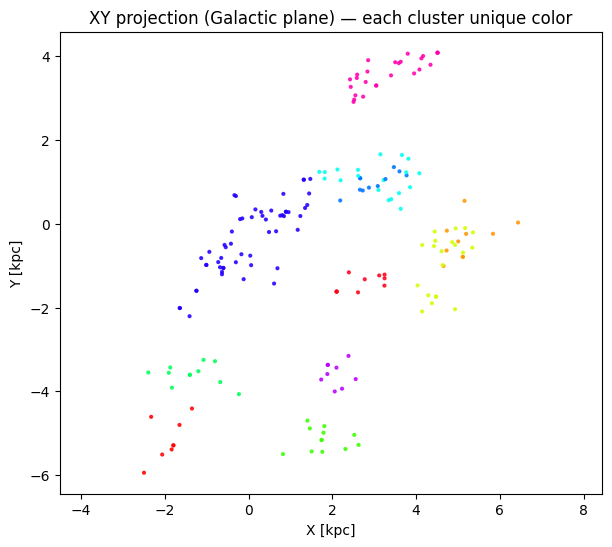

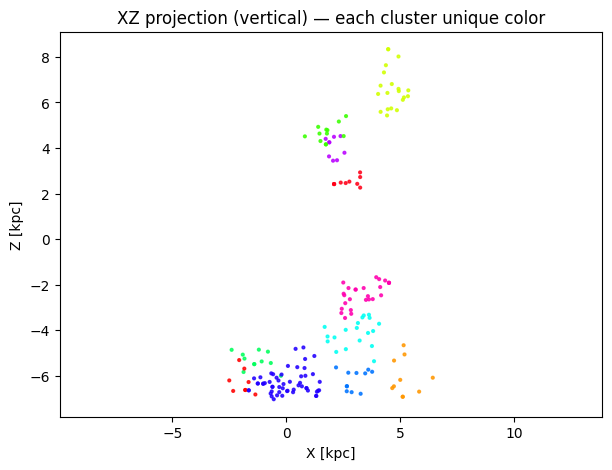

In [31]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Filter data
df = out["per_source_df"]
df_sel = df[df["cluster_radial_align"] < 0.7].copy()

mask = np.isin(res["index_valid"], df_sel.index)
x = np.asarray(res["x"])[mask]
y = np.asarray(res["y"])[mask]
z = np.asarray(res["z"])[mask]
labels = df_sel["cluster_id"].values

# Get all unique cluster IDs (excluding noise -1 if desired)
unique_labels = np.unique(labels)
unique_labels = unique_labels[unique_labels != -1]

# Generate distinct colors for each cluster using a perceptually uniform colormap
colors = plt.cm.get_cmap('hsv', len(unique_labels))

# Map cluster_id → unique color
label_to_color = {cid: colors(i) for i, cid in enumerate(unique_labels)}
cmap_arr = np.array([label_to_color.get(cid, (0.6, 0.6, 0.6, 0.3)) for cid in labels])

# XY projection
plt.figure(figsize=(7,6))
plt.scatter(x, y, c=cmap_arr, s=4, alpha=0.8)
plt.xlabel("X [kpc]")
plt.ylabel("Y [kpc]")
plt.title("XY projection (Galactic plane) — each cluster unique color")
plt.axis("equal")
plt.show()

# XZ projection
plt.figure(figsize=(7,5))
plt.scatter(x, z, c=cmap_arr, s=4, alpha=0.8)
plt.xlabel("X [kpc]")
plt.ylabel("Z [kpc]")
plt.title("XZ projection (vertical) — each cluster unique color")
plt.axis("equal")
plt.show()

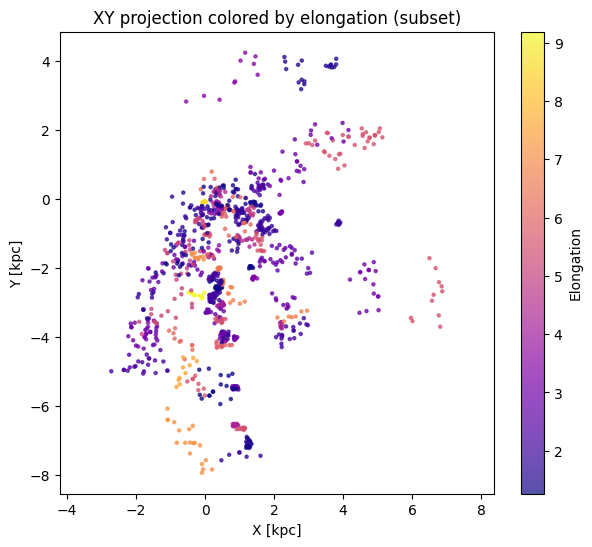

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# df is your already-filtered per_source_df (e.g., radial_align < 0.7)
elong = df_sel["cluster_elongation"].to_numpy()

# Build a mask to select the same rows in res["x"], res["y"], res["z"]
mask = np.isin(res["index_valid"], df_sel.index)

x = np.asarray(res["x"])[mask]
y = np.asarray(res["y"])[mask]

# Optional: drop NaNs in elongation to keep lengths consistent
valid = np.isfinite(elong)
x, y, elong = x[valid], y[valid], elong[valid]

plt.figure(figsize=(7,6))
sc = plt.scatter(x, y, c=elong, s=5, cmap="plasma", alpha=0.7)
plt.xlabel("X [kpc]")
plt.ylabel("Y [kpc]")
plt.title("XY projection colored by elongation (subset)")
plt.colorbar(sc, label="Elongation")
plt.axis("equal")
plt.show()

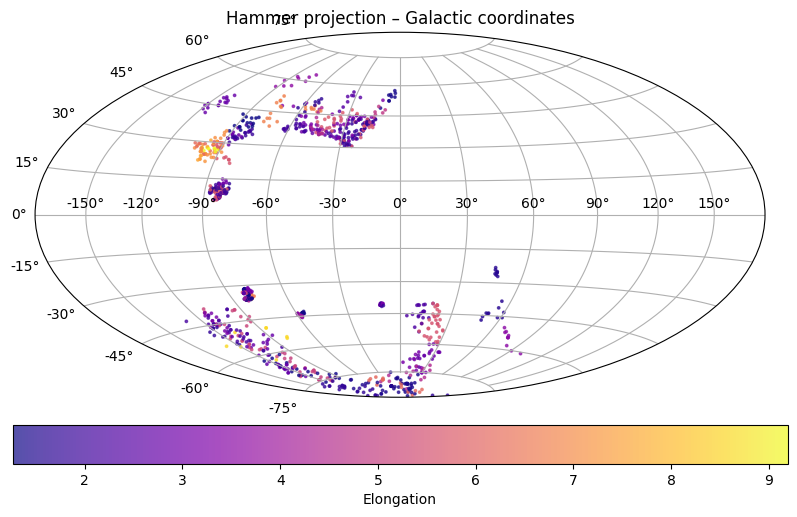

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# df_sel: your filtered per-source table
# elong:  same-length array/Series with elongation for df_sel rows

# 1) Convert RA/Dec -> Galactic (l,b) using your function
l_deg, b_deg = radec_to_galactic(df_sel["ra"].to_numpy(), df_sel["dec"].to_numpy())

# 2) Wrap longitude to [-180, 180] then to radians (Hammer expects [-pi, pi])
l_wrap_deg = (l_deg + 180.0) % 360.0 - 180.0
l_rad = np.radians(l_wrap_deg)
b_rad = np.radians(b_deg)

# 3) Keep only finite points (avoid NaNs messing the projection)
elong_arr = np.asarray(elong)
valid = np.isfinite(l_rad) & np.isfinite(b_rad) & np.isfinite(elong_arr)

plt.figure(figsize=(10, 6))
ax = plt.subplot(111, projection="hammer")
sc = ax.scatter(l_rad[valid], b_rad[valid], c=elong_arr[valid], s=3, cmap="plasma", alpha=0.7)
ax.grid(True)
plt.title("Hammer projection – Galactic coordinates")
cb = plt.colorbar(sc, orientation="horizontal", pad=0.06)
cb.set_label("Elongation")
plt.show()

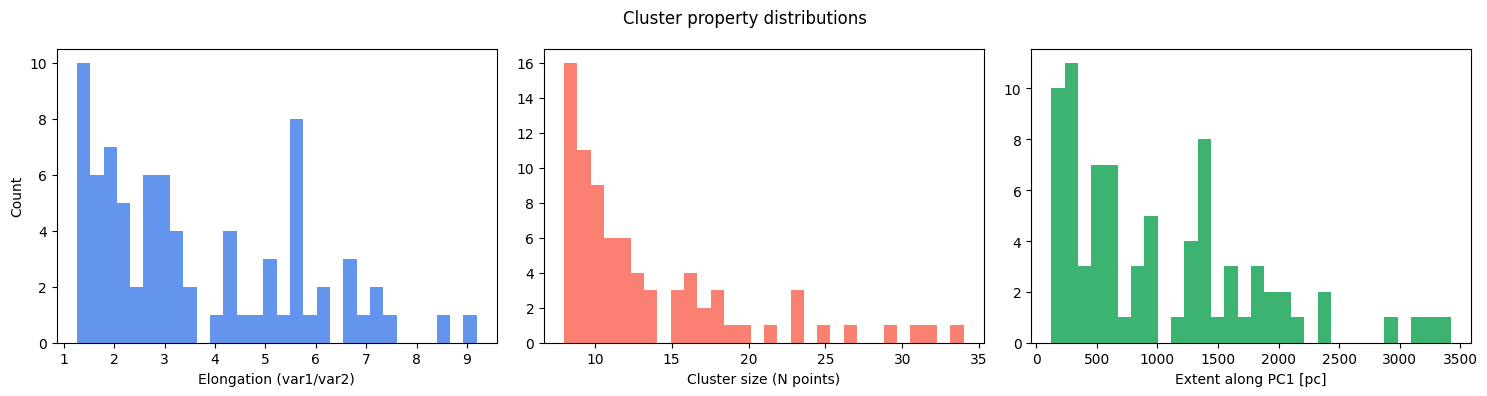

In [40]:
fig, axs = plt.subplots(1,3,figsize=(15,4))
axs[0].hist(shape["elongation"], bins=30, color='cornflowerblue')
axs[0].set_xlabel("Elongation (var1/var2)")
axs[0].set_ylabel("Count")

axs[1].hist(shape["n"], bins=30, color='salmon')
axs[1].set_xlabel("Cluster size (N points)")

axs[2].hist(shape["extent_pc_1"], bins=30, color='mediumseagreen')
axs[2].set_xlabel("Extent along PC1 [pc]")

plt.suptitle("Cluster property distributions")
plt.tight_layout()
plt.show()

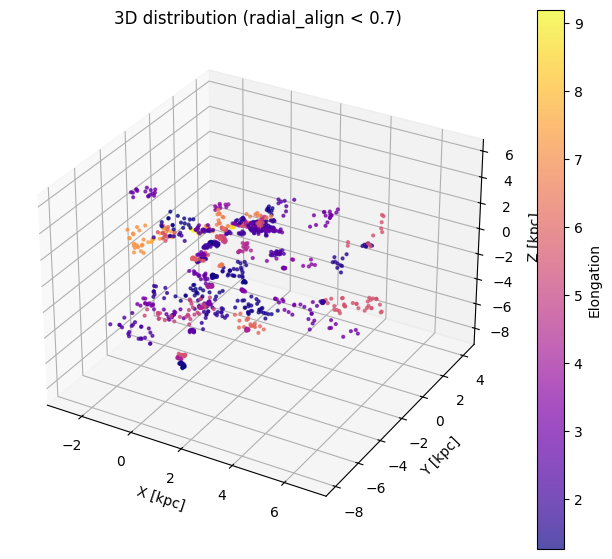

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# df_sel = out["per_source_df"][out["per_source_df"]["cluster_radial_align"] < 0.7]
df_sel = out["per_source_df"].loc[out["per_source_df"]["cluster_radial_align"] < 0.7].copy()

# Align with res arrays
mask = np.isin(res["index_valid"], df_sel.index)
x = np.asarray(res["x"])[mask]
y = np.asarray(res["y"])[mask]
z = np.asarray(res["z"])[mask]

elong = df_sel["cluster_elongation"].to_numpy()
valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z) & np.isfinite(elong)

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(x[valid], y[valid], z[valid], c=elong[valid], s=4, cmap="plasma", alpha=0.7)
ax.set_xlabel("X [kpc]"); ax.set_ylabel("Y [kpc]"); ax.set_zlabel("Z [kpc]")
fig.colorbar(p, label="Elongation")
plt.title("3D distribution (radial_align < 0.7)")
plt.show()

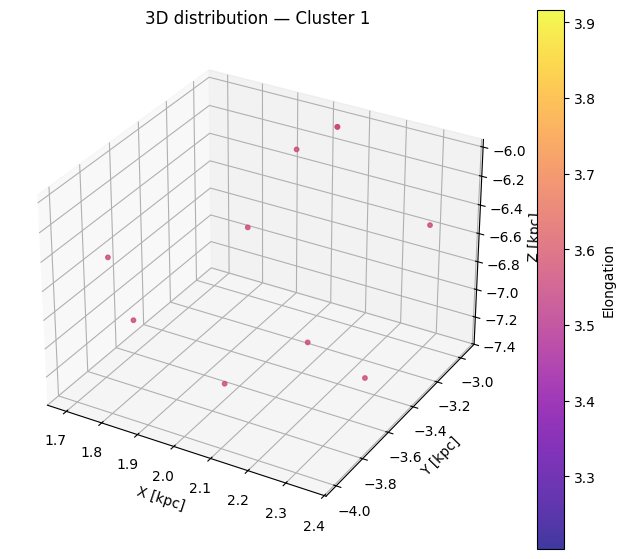

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Choose which cluster you want to see
target_cluster = 1  # <-- change to the cluster ID you want

# Filter for that one cluster
df_one = out["per_source_df"].loc[out["per_source_df"]["cluster_id"] == target_cluster].copy()

# Align with res arrays
mask = np.isin(res["index_valid"], df_one.index)
x = np.asarray(res["x"])[mask]
y = np.asarray(res["y"])[mask]
z = np.asarray(res["z"])[mask]

# Color by elongation (or any property you like)
elong = df_one["cluster_elongation"].to_numpy()
valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z) & np.isfinite(elong)

# 3D scatter plot
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(x[valid], y[valid], z[valid], c=elong[valid], s=10, cmap="plasma", alpha=0.8)
ax.set_xlabel("X [kpc]")
ax.set_ylabel("Y [kpc]")
ax.set_zlabel("Z [kpc]")
fig.colorbar(p, label="Elongation")
plt.title(f"3D distribution — Cluster {target_cluster}")
plt.show()

In [34]:
summary = shape[["cluster","n","elongation","extent_pc_1","extent_pc_2","extent_pc_3","radial_align"]]
summary.describe().T

,count,mean,std,min,25%,50%,75%,max
cluster,79.0,95.265823,76.713872,0.000000,34.000000,72.000000,128.500000,262.000000
n,79.0,13.329114,6.209425,8.000000,9.000000,11.000000,16.000000,34.000000
elongation,79.0,3.652907,2.005846,1.261665,1.894304,3.024217,5.479440,9.190793
extent_pc_1,79.0,1017.582997,801.392430,122.422127,336.335634,794.296309,1426.109161,3423.642816
extent_pc_2,79.0,577.501193,452.660793,61.342470,204.568588,441.228590,896.559671,1831.486501
extent_pc_3,79.0,327.829928,276.296975,26.076626,115.027957,219.423699,497.270498,1074.798543
radial_align,79.0,0.359549,0.209140,0.042262,0.171927,0.330970,0.561539,0.691285


In [35]:
summary

,cluster,n,elongation,extent_pc_1,extent_pc_2,extent_pc_3,radial_align
23,24,34,5.557921,2913.404098,1235.789669,1023.599064,0.266373
87,102,32,1.834814,625.224002,461.572186,247.227772,0.510555
34,38,31,1.386357,1661.374412,1411.009759,1037.738388,0.138814
77,90,29,1.897655,835.443975,606.469200,332.611786,0.312295
27,28,27,1.787233,2050.255690,1533.618810,1074.798543,0.366185
...,...,...,...,...,...,...,...
41,46,8,2.496350,1343.946766,850.607801,357.915450,0.208272
56,67,8,1.838945,553.309532,408.022153,155.515028,0.645227
110,127,8,1.732230,229.480010,174.358072,126.680626,0.182616
37,42,8,1.588415,555.167183,440.495843,149.178788,0.070740


In [32]:
import numpy as np
import matplotlib.pyplot as plt

def plot_aitoff_galactic(l_deg,
                         b_deg,
                         band_halfwidth_deg=10,
                         title="Skymap (Aitoff, Galactic coords)",
                         s=6,
                         alpha=0.7,
                         color="C0",
                         grid_step_deg=60,
                         show_gc=True,
                         figsize=(10, 6)):
    """
    Plot an Aitoff skymap in Galactic coordinates (l,b) and emphasize the Galactic disk.

    Parameters
    ----------
    l_deg, b_deg : array-like
        Galactic longitude and latitude in DEGREES. Longitudes can be [0,360) or [-180,180).
    band_halfwidth_deg : float, optional
        Half-width of the highlighted Galactic plane band around b=0 (in degrees).
    title : str
        Figure title.
    s : float
        Marker size for the scatter points.
    alpha : float
        Alpha for the scatter points.
    color : str
        Color for the scatter points.
    grid_step_deg : int
        Grid spacing for longitude lines (in degrees).
    show_gc : bool
        If True, marks the Galactic Center at (l=0°, b=0°).
    figsize : tuple
        Matplotlib figure size.
    """
    # --- prep data ---
    l_deg = np.asarray(l_deg, dtype=float)
    b_deg = np.asarray(b_deg, dtype=float)

    # Wrap longitudes to [-180, 180) so Aitoff looks continuous
    l_wrap = ((l_deg + 180.0) % 360.0) - 180.0

    # Convert to radians for Aitoff
    l_rad = np.radians(l_wrap)
    b_rad = np.radians(b_deg)

    # --- figure/axes ---
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="aitoff")

    # Shaded Galactic plane band: |b| <= band_halfwidth_deg
    bw = np.radians(band_halfwidth_deg)
    # Fill across full longitude range with two polygons (top and bottom) merged by fill_between-like trick
    lon_fill = np.linspace(-np.pi, np.pi, 720)
    ax.fill_between(lon_fill, +bw, -bw, transform=ax.get_xaxis_transform(),
                    alpha=0.15, zorder=0)

    # Scatter points
    ax.scatter(l_rad, b_rad, s=s, alpha=alpha, color=color, rasterized=True)

    # Mark Galactic Center (l=0, b=0)
    if show_gc:
        ax.plot([0], [0], marker="*", ms=10, color="crimson", zorder=3)
        ax.text(0.03, 0.03, "GC", transform=ax.transAxes, color="crimson")

    # Grid and ticks labeled in degrees
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    # Re-label default xticks (in radians) to degrees, with l increasing to the left (Aitoff convention)
    xticks_rad = np.radians(np.arange(-180, 181, grid_step_deg))
    ax.set_xticks(xticks_rad)
    ax.set_xticklabels([f"{int(t)}°" for t in np.degrees(xticks_rad)])

    ax.set_title(title, pad=20)
    plt.tight_layout()
    return fig, ax

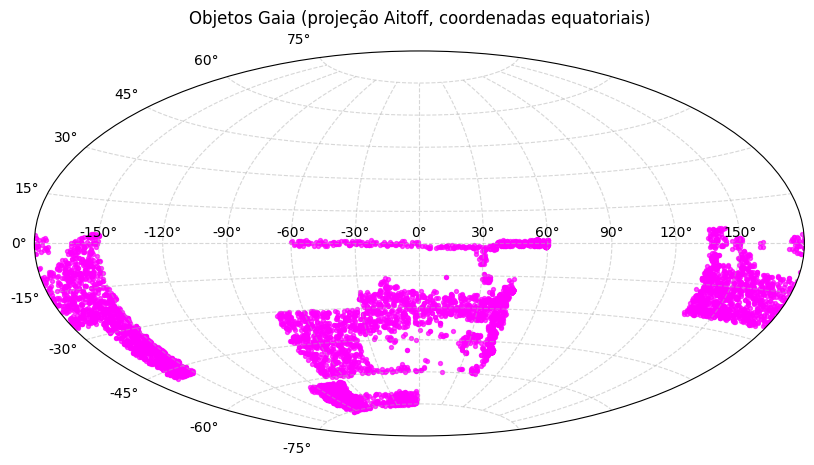

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Exemplo: DataFrame com colunas ra e dec (em graus)
# df = pd.DataFrame({'ra': [...], 'dec': [...]})

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection="aitoff")

# Converte RA (em horas) para radianos e ajusta para [-π, +π]
ra_rad = np.radians(df['ra'].to_numpy())
dec_rad = np.radians(df['dec'].to_numpy())
ra_rad = np.remainder(ra_rad + 2*np.pi, 2*np.pi)  # wrap
ra_rad[ra_rad > np.pi] -= 2*np.pi                 # centraliza em 0h
ra_rad = -ra_rad                                  # RA cresce para a esquerda

ax.scatter(ra_rad, dec_rad, s=8, color="magenta", alpha=0.7)

ax.grid(True, linestyle="--", alpha=0.5)
ax.set_title("Objetos Gaia (projeção Aitoff, coordenadas equatoriais)", pad=20)
plt.show()